# Introdução

A análise por transformada de Fourier é o principal mecanismo para identificar os espectros das frequências das imagens. Através dela também, podemos realizar a aplicação de filtros apenas com a multiplicação no domínio da frequência.

# Utilizando a fft
## Testes iniciais

Para visualizar o espectro de frequencias de uma imagem, podemos

In [46]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [47]:
def mostrar(imagens: list, titulos=[], cmaps=[], eixos = False, minmax=None):
    if type(imagens) == list:
        if type(imagens[0]) == list:
            fig, axs = plt.subplots(len(imagens), len(imagens[0]), figsize=(5*len(imagens[0]), 5*len(imagens)))
            for i in range(len(imagens)):
                for j in range(len(imagens[i])):
                    imagem = imagens[i][j]
                    if cmaps[i][j]:
                        axs[i][j].imshow(imagem, cmap=cmaps[i][j])
                    else:
                        axs[i][j].imshow(imagem)
                    if titulos[i][j]:
                        axs[i][j].set_title(titulos[i][j])
                    if not eixos:
                        axs[i][j].axis("off")
        else:
            fig, axs = plt.subplots(1, len(imagens), figsize=(20, 20))
            for i, imagem in enumerate(imagens):
                print(axs)
                if cmaps:
                    axs[i].imshow(imagem, cmap=cmaps[i])
                else:
                    axs[i].imshow(imagem)
                if titulos:
                    axs[i].set_title(titulos[i])
                if not eixos:
                    axs[i].axis("off")
        #diminui distancia lateral
        plt.subplots_adjust(wspace=0.1, hspace=0.1)
    else:
        if type(cmaps) != list:
            plt.imshow(imagens, cmap=cmaps)
        else:
            plt.imshow(imagens)
        if type(titulos) != list:
            plt.title(titulos)
        if not eixos:
            plt.axis("off")
    plt.show()
    

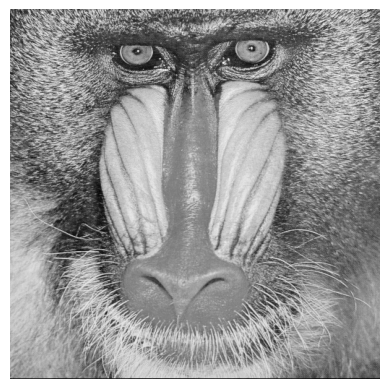

In [48]:
# carrega a imagem baboon.png usando cv2
img = cv2.imread('imagens/baboon.png')[:,:,0]
# exibe a imagem usando matplotlib
mostrar(img, cmaps='gray')


[[11.65597786 12.60902892 11.87603936 ... 13.3417161  11.87603936
  12.60902892]
 [12.17762191 11.90918834 11.97721686 ... 12.8042176   9.75168758
  10.66946466]
 [11.83416412 11.48636997 11.27699644 ... 11.76929993 11.64526518
   8.69928047]
 ...
 [11.87823335 10.33971722  9.39510144 ... 11.37013463 12.41730573
  10.82628783]
 [11.83416412  8.69928047 11.64526518 ... 12.56918738 11.27699644
  11.48636997]
 [12.17762191 10.66946466  9.75168758 ... 12.17902138 11.97721686
  11.90918834]]
[<Axes: > <Axes: > <Axes: > <Axes: >]
[<Axes: title={'center': 'Parte Real da FFT'}> <Axes: > <Axes: > <Axes: >]
[<Axes: title={'center': 'Parte Real da FFT'}>
 <Axes: title={'center': 'Parte Imaginaria da FFT'}> <Axes: > <Axes: >]
[<Axes: title={'center': 'Parte Real da FFT'}>
 <Axes: title={'center': 'Parte Imaginaria da FFT'}>
 <Axes: title={'center': 'Modulo da FFT'}> <Axes: >]


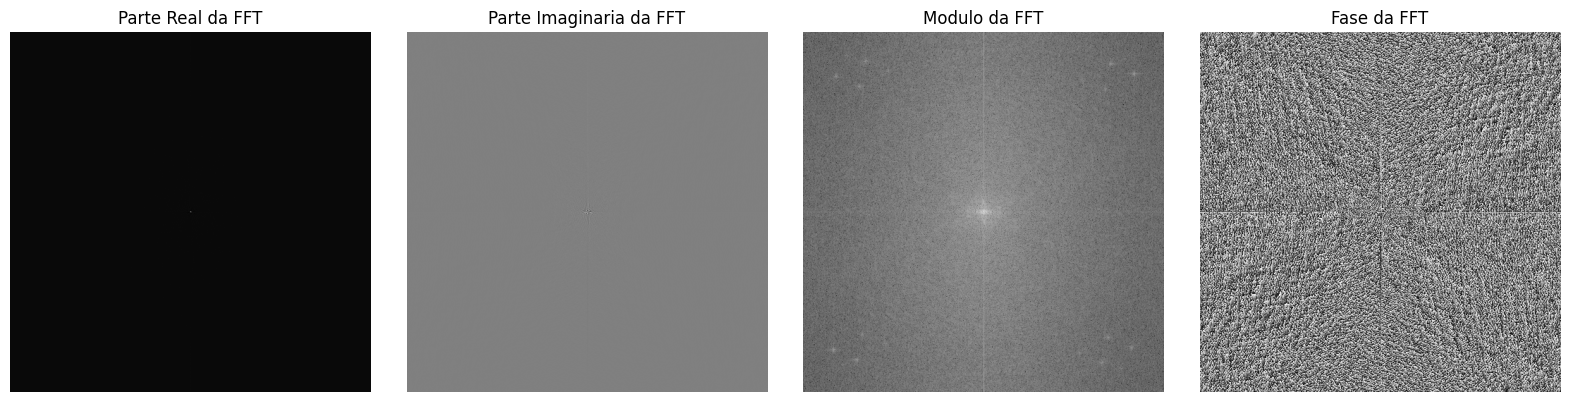

In [74]:
import numpy as np
# obtem a fft da imagem:
img_fft = np.fft.fftshift(np.fft.fft2(img))
img_fft_modulo =np.abs(img_fft)
# 
# img_fft_modulo = np.clip((img_fft_modulo)/np.mean(img_fft_modulo)*(255/2), 0, 255).astype(np.uint8)
img_fft_modulo = np.log(img_fft_modulo+1)
print(img_fft_modulo)
# exibe a parte real, a parte imaginaria, o modulo e a fase da fft da imagem
mostrar([np.real(img_fft), np.imag(img_fft), img_fft_modulo, np.angle(img_fft)], ["Parte Real da FFT", "Parte Imaginaria da FFT", "Modulo da FFT", "Fase da FFT"], ["gray"]*4)
